# Loan Default Risk Classifier with PyTorch
### A Prodigy Training Hub Masterclass — Nigerian Banking & Microfinance Edition

This notebook builds a **multi-class** loan default risk prediction model that classifies each loan applicant into one of four risk categories:

| Label | Meaning | Recommended Action |
|---|---|---|
| **Low Risk** | Very likely to repay without issues | Approve at standard terms |
| **Medium Risk** | Generally reliable but some risk indicators present | Approve with closer monitoring |
| **High Risk** | Material default indicators — proceed with caution | Require stronger collateral or guarantor |
| **Default** | High probability of non-repayment | Decline or require restructuring |

This is a **direct extension** of the earlier binary churn classifier, upgraded in three important ways:
1. **More features** — 46 columns covering demographics, employment, income structure, loan terms, collateral, banking behaviour, and full repayment/credit history.
2. **Multi-class target** — four output classes instead of two, using `nn.CrossEntropyLoss` instead of `nn.BCEWithLogitsLoss`.
3. **Richer evaluation** — per-class precision/recall/F1, a 4×4 confusion matrix, and One-vs-Rest ROC curves for all four classes simultaneously.

**Dataset:** `nigerian_loan_default_dataset.csv` / `.xlsx` — 10,000 synthetic but realistically-structured loan applications for a fictional Nigerian bank or microfinance institution.

---


## 0. Setup and Imports


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, roc_auc_score,
    classification_report
)

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch version :", torch.__version__)
print("Device          :", device)

# Class constants — we will use these throughout the notebook
CLASSES       = ["Low Risk", "Medium Risk", "High Risk", "Default"]
CLASS_COLORS  = ["#27AE60", "#F39C12", "#E74C3C", "#8E44AD"]
NUM_CLASSES   = len(CLASSES)
print("\nRisk classes:", CLASSES)


PyTorch version : 2.12.1+cu130
Device          : cpu

Risk classes: ['Low Risk', 'Medium Risk', 'High Risk', 'Default']


## 1. Loading and First Look at the Dataset


In [2]:
df = pd.read_csv("nigerian_loan_default_dataset.csv")
print("Shape:", df.shape)
print("\nFirst 3 rows:")
df.head(3)


Shape: (10000, 46)

First 3 rows:


,loan_id,gender,age,marital_status,education_level,state,region,area_type,number_of_dependents,employment_type,...,guarantor_available,num_previous_loans,num_previous_defaults,previous_loan_completion_rate_pct,missed_payments_last_12mo,days_overdue_on_previous,payment_consistency_score_1to10,credit_score_internal,loan_officer_risk_rating,loan_default_risk
0,LN200000,Female,18,Married,Secondary / O-Level,Plateau,North Central,Urban,3,Contractor,...,Yes,1,0,99.3,1,0.0,9.6,764,Low,Medium Risk
1,LN200001,Male,47,Single,HND / B.Sc,Cross River,South South,Suburban,4,Salaried,...,Yes,2,1,55.0,0,69.0,6.7,771,Low,Low Risk
2,LN200002,Female,48,Single,No Formal Education,Lagos,South West,Suburban,2,Contractor,...,Yes,0,0,100.0,1,0.0,8.1,701,Low,Medium Risk


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 46 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   loan_id                            10000 non-null  str    
 1   gender                             10000 non-null  str    
 2   age                                10000 non-null  int64  
 3   marital_status                     10000 non-null  str    
 4   education_level                    10000 non-null  str    
 5   state                              10000 non-null  str    
 6   region                             10000 non-null  str    
 7   area_type                          10000 non-null  str    
 8   number_of_dependents               10000 non-null  int64  
 9   employment_type                    10000 non-null  str    
 10  employer_sector                    9479 non-null   str    
 11  years_in_employment                10000 non-null  float64
 12  mo

In [4]:
# Missing value audit
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)
total_cells = df.shape[0] * df.shape[1]
print(f"\nTotal missing: {missing.sum()} / {total_cells} ({missing.sum()/total_cells*100:.3f}%)")


Columns with missing values:
collateral_type                      1983
employer_sector                       521
property_value_naira                  180
days_overdue_on_previous              150
other_income_sources_naira            120
previous_loan_completion_rate_pct     100
payment_consistency_score_1to10        80
dtype: int64

Total missing: 3134 / 460000 (0.681%)


In [5]:
# Numeric summary
df.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
age,10000.0,36.27,9.73,18.00,29.00,36.00,43.00,72.00
number_of_dependents,10000.0,2.42,1.56,0.00,1.00,2.00,3.00,9.00
years_in_employment,10000.0,9.42,6.44,0.00,4.70,8.30,12.90,35.00
monthly_income_naira,10000.0,184826.70,144602.24,8000.00,80000.00,151000.00,252000.00,1487000.00
other_income_sources_naira,9880.0,12983.70,25487.52,0.00,0.00,0.00,17000.00,328000.00
total_monthly_income_naira,10000.0,197794.20,146800.80,8000.00,92000.00,165000.00,268000.00,1487000.00
monthly_expenses_naira,10000.0,137544.28,93660.29,5000.00,72000.00,119000.00,182000.00,1034000.00
net_monthly_income_naira,10000.0,60245.40,68900.75,0.00,8000.00,39000.00,87000.00,742000.00
savings_balance_naira,10000.0,886605.80,1037054.45,0.00,237750.00,557000.00,1155000.00,18594000.00
current_account_balance_naira,10000.0,428656.60,575698.33,0.00,87000.00,231000.00,547250.00,7279000.00


In [6]:
# Categorical summary
df.describe(include="object").T


,count,unique,top,freq
loan_id,10000,10000,LN200000,1
gender,10000,2,Male,5742
marital_status,10000,4,Married,5552
education_level,10000,6,HND / B.Sc,4238
state,10000,16,Lagos,2184
region,10000,6,South West,3322
area_type,10000,3,Urban,5204
employment_type,10000,5,Salaried,4258
employer_sector,9479,14,Other,1378
owns_property,10000,2,No,6187


## 2. Exploring the Target Variable: `loan_default_risk`

Unlike the binary churn problem, we now have **four ordered categories**. The class distribution directly informs our evaluation strategy and how we handle class imbalance during training.


Class Distribution:
---------------------------------------------
  Low Risk         3500 ( 35.0%)  █████████████████
  Medium Risk      3000 ( 30.0%)  ███████████████
  High Risk        2300 ( 23.0%)  ███████████
  Default          1200 ( 12.0%)  ██████


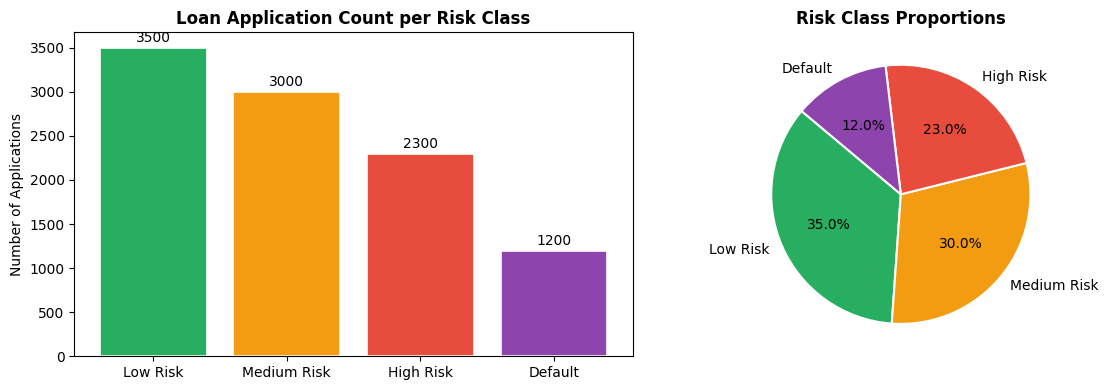

In [7]:
counts = df["loan_default_risk"].value_counts().reindex(CLASSES)
pcts   = df["loan_default_risk"].value_counts(normalize=True).reindex(CLASSES) * 100

print("Class Distribution:")
print("-" * 45)
for cls, cnt, pct in zip(CLASSES, counts.values, pcts.values):
    bar = "█" * int(pct / 2)
    print(f"  {cls:<15} {cnt:>5} ({pct:5.1f}%)  {bar}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(CLASSES, counts.values, color=CLASS_COLORS, edgecolor="white", linewidth=1.2)
axes[0].set_title("Loan Application Count per Risk Class", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Number of Applications")
for bar, cnt in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                  str(cnt), ha="center", va="bottom", fontsize=10)

# Pie chart
axes[1].pie(counts.values, labels=CLASSES, autopct="%1.1f%%",
            colors=CLASS_COLORS, startangle=140,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[1].set_title("Risk Class Proportions", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()


**Reading this distribution:**

The dataset is **imbalanced across all four classes**, with Low Risk being the majority class (35%) and Default the smallest (12%). This is intentional and realistic — a well-run credit institution should have far more successful loans than defaults, but the minority Default class is precisely the one that matters most to the business. When we configure our loss function, we will use **class weights** to prevent the model from learning to simply predict the three larger classes most of the time while missing actual defaults.

Also note: the classes are **ordered** — Low Risk < Medium Risk < High Risk < Default — which means errors adjacent to the truth (e.g. predicting Medium Risk for a High Risk applicant) are less severe than extreme errors (predicting Low Risk for a Default applicant). This ordinal nature will be visible in the confusion matrix later.


## 3. Exploring Risk Drivers: Categorical Features

For each categorical feature, we compute the **proportion of applicants in each risk class** within each category and plot it as a stacked horizontal bar chart — revealing which categories are systematically associated with higher or lower risk.


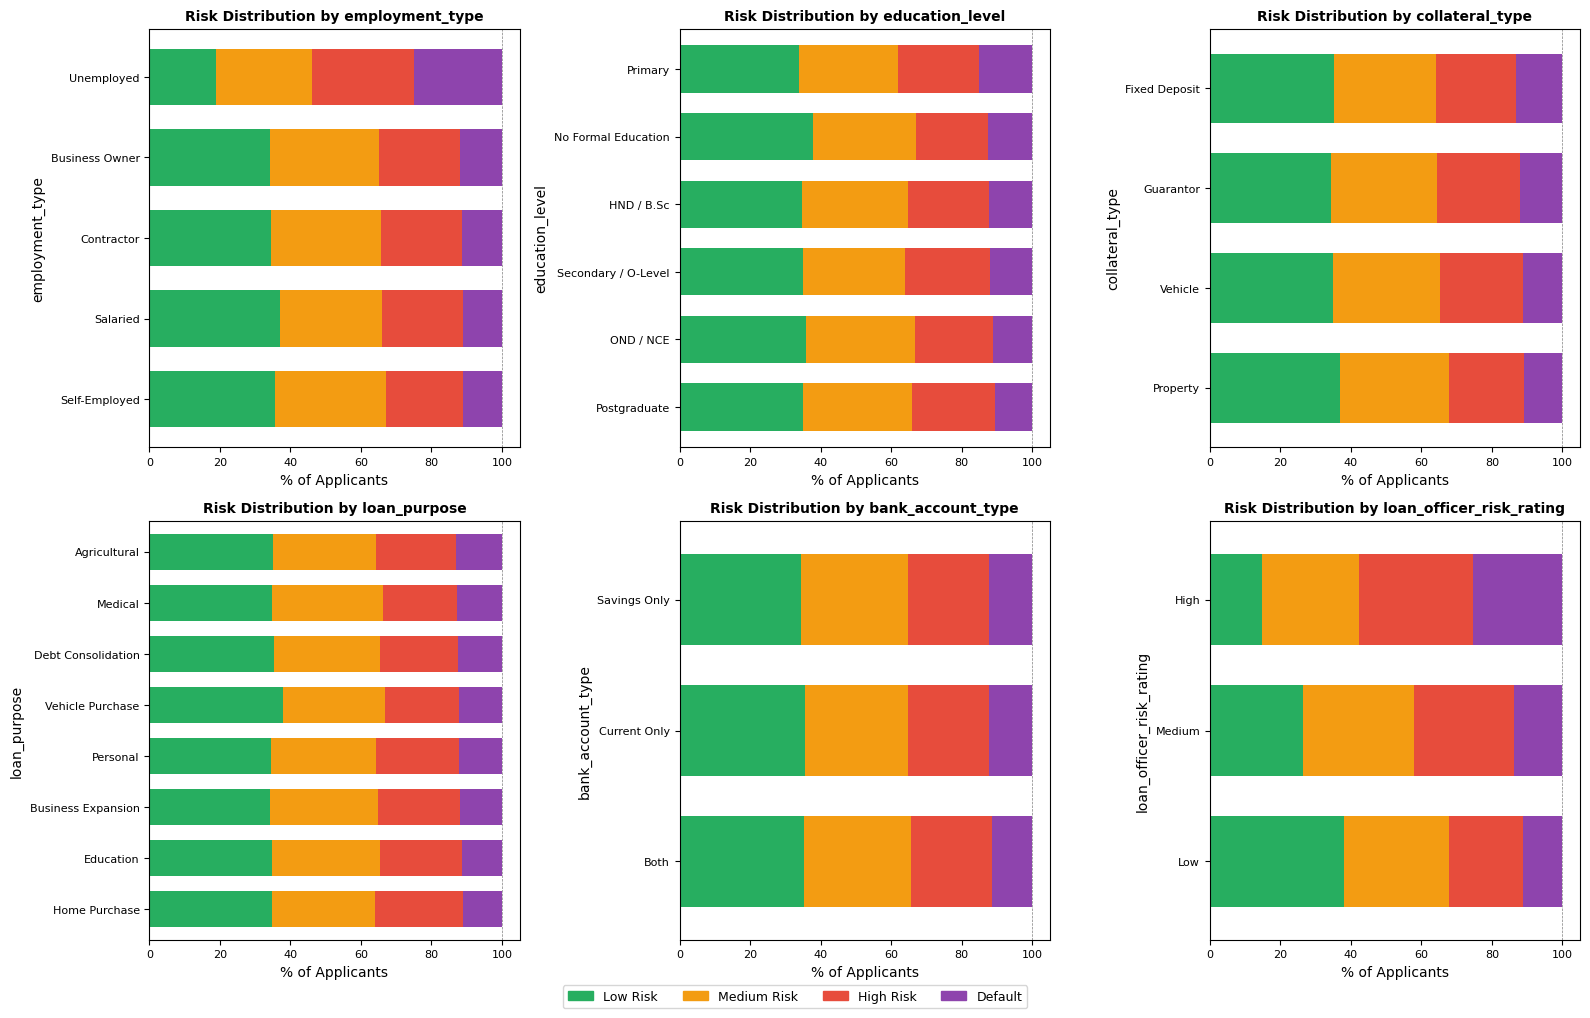

In [8]:
def stacked_risk_chart(col, ax, title=None, top_n=8):
    """Stacked bar chart showing the risk-class breakdown for each category of `col`."""
    grp = df.groupby([col, "loan_default_risk"]).size().unstack(fill_value=0)
    grp = grp.reindex(columns=CLASSES, fill_value=0)
    grp_pct = grp.div(grp.sum(axis=1), axis=0) * 100
    # Keep only top_n most frequent categories
    freq = df[col].value_counts().head(top_n).index
    grp_pct = grp_pct.loc[grp_pct.index.isin(freq)]
    # Sort by Default proportion (most dangerous at top)
    grp_pct = grp_pct.sort_values("Default", ascending=True)

    grp_pct.plot(kind="barh", stacked=True, ax=ax, color=CLASS_COLORS,
                  width=0.7, legend=False)
    ax.set_title(title or f"Risk Distribution by {col}", fontsize=10, fontweight="bold")
    ax.set_xlabel("% of Applicants")
    ax.axvline(100, color="gray", linewidth=0.5, linestyle="--")
    ax.tick_params(labelsize=8)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

stacked_risk_chart("employment_type", axes[0])
stacked_risk_chart("education_level", axes[1])
stacked_risk_chart("collateral_type", axes[2])
stacked_risk_chart("loan_purpose", axes[3])
stacked_risk_chart("bank_account_type", axes[4])
stacked_risk_chart("loan_officer_risk_rating", axes[5])

# Legend
patches = [mpatches.Patch(color=c, label=l) for c,l in zip(CLASS_COLORS, CLASSES)]
fig.legend(handles=patches, loc="lower center", ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()


**Key observations from these charts:**

- **Employment type:** Unemployed applicants show dramatically more Default and High Risk segments than Salaried or Business Owner applicants. Salaried workers have the largest Low Risk proportion — consistent with stable, predictable income.
- **Education level:** Higher education correlates with lower default rates — postgraduate applicants skew heavily toward Low Risk, while applicants with no formal education have substantially more High Risk and Default segments.
- **Collateral type:** Fixed Deposit and Property-backed loans skew toward Low Risk (the collateral reduces the lender's exposure and likely signals a more financially stable applicant). Uncollateralised (None) loans show more Default proportions.
- **Loan purpose:** Debt Consolidation loans show notably more Default proportions — borrowers consolidating debt may already be in financial difficulty. Business Expansion and Home Purchase tend to produce better risk profiles.
- **Bank account type:** Customers with both Savings and Current accounts show better risk profiles than those with only one, possibly reflecting greater financial engagement and stability.
- **Loan officer risk rating:** This human-assigned rating tracks the actual outcome well, validating that the officer's subjective judgment carries real information — though the model will be able to identify non-obvious patterns the officer cannot.


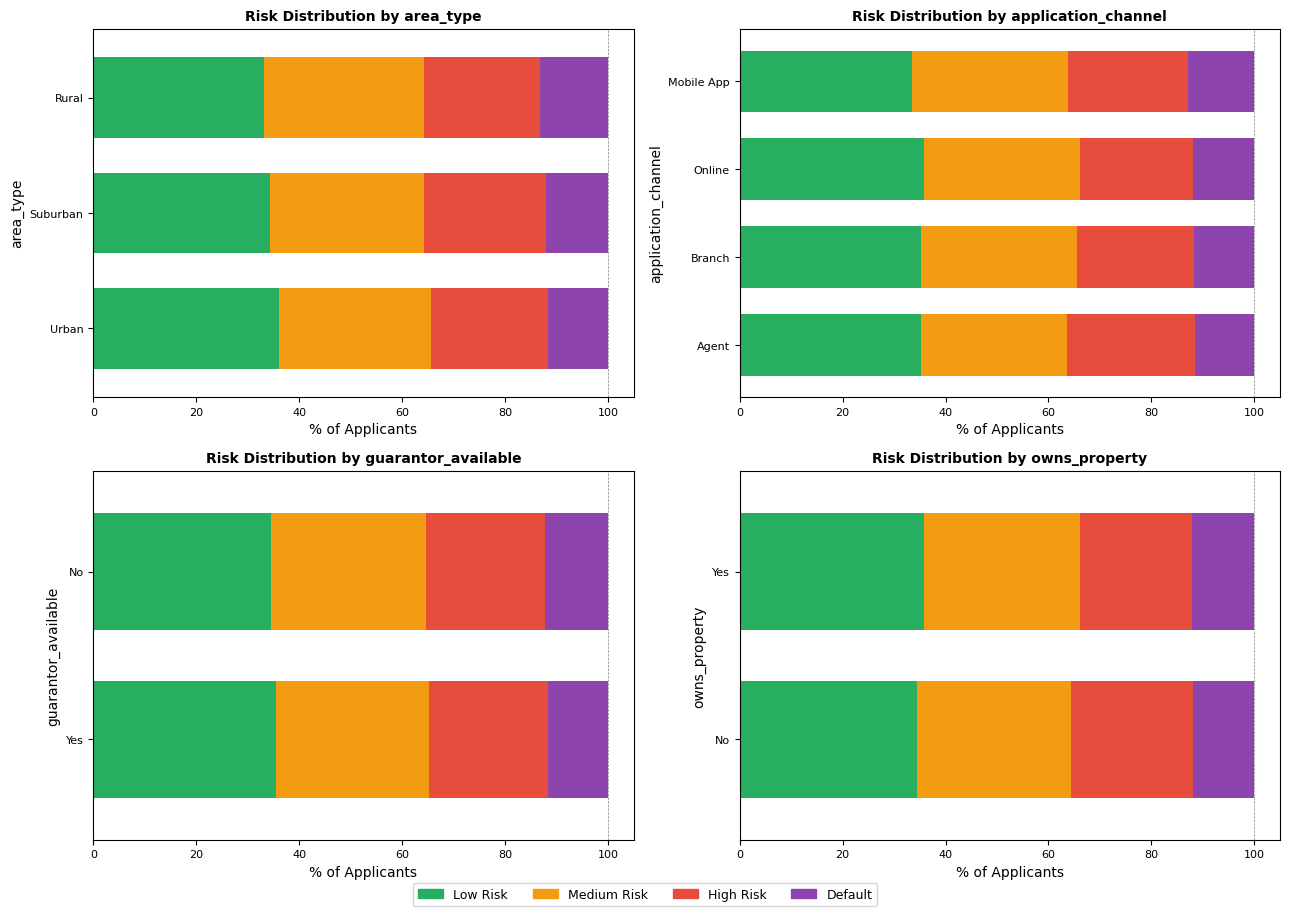

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

stacked_risk_chart("area_type", axes[0])
stacked_risk_chart("application_channel", axes[1])
stacked_risk_chart("guarantor_available", axes[2])
stacked_risk_chart("owns_property", axes[3])

fig.legend(handles=patches, loc="lower center", ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()


## 4. Exploring Risk Drivers: Numeric Features

Box plots comparing the distribution of key numeric features across the four risk classes reveal which numeric features discriminate well between classes.


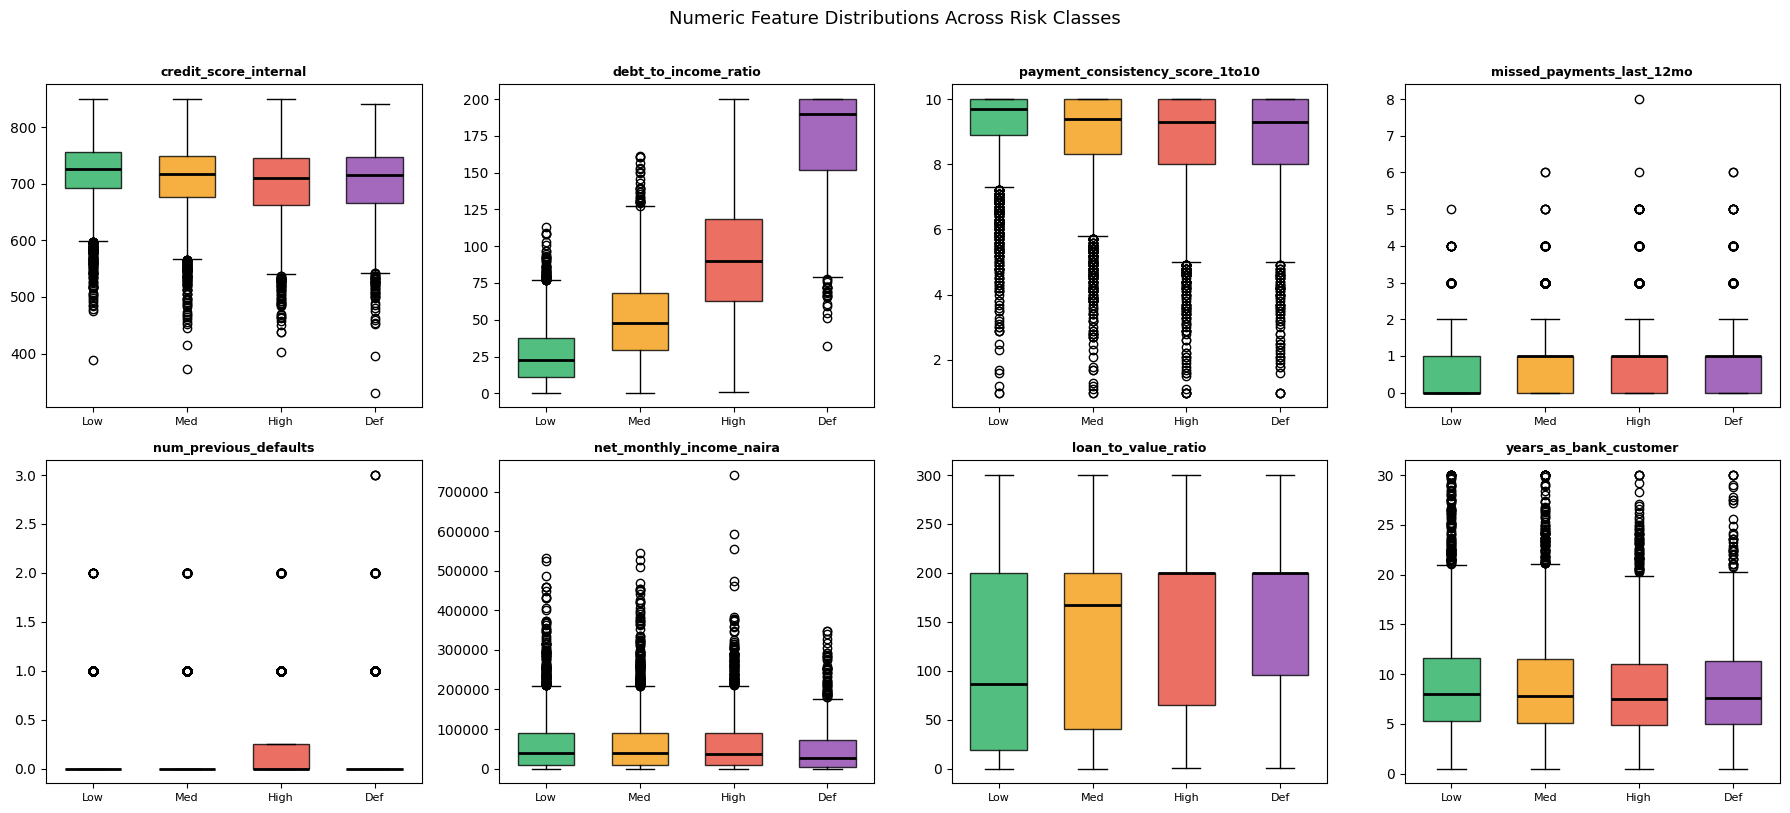

In [10]:
numeric_features_to_plot = [
    "credit_score_internal",
    "debt_to_income_ratio",
    "payment_consistency_score_1to10",
    "missed_payments_last_12mo",
    "num_previous_defaults",
    "net_monthly_income_naira",
    "loan_to_value_ratio",
    "years_as_bank_customer",
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(numeric_features_to_plot):
    data_by_class = [df.loc[df["loan_default_risk"]==cls, feat].dropna() for cls in CLASSES]
    bp = axes[i].boxplot(data_by_class, patch_artist=True, widths=0.6,
                          medianprops={"color":"black","linewidth":2})
    for patch, col in zip(bp["boxes"], CLASS_COLORS):
        patch.set_facecolor(col)
        patch.set_alpha(0.8)
    axes[i].set_xticks([1,2,3,4])
    axes[i].set_xticklabels(["Low","Med","High","Def"], fontsize=8)
    axes[i].set_title(feat, fontsize=9, fontweight="bold")

plt.suptitle("Numeric Feature Distributions Across Risk Classes", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()


**Reading the box plots:**

- **`credit_score_internal`:** only mild separation — the model was constructed to not make this a perfectly discriminating feature, reflecting reality where credit score alone does not predict default perfectly.
- **`debt_to_income_ratio`:** dramatic separation — Default class has a dramatically higher median DTI than Low Risk. This is the single most visually obvious numeric separator in the dataset.
- **`payment_consistency_score_1to10`:** inverse relationship — Default applicants score lower, Low Risk score higher. A meaningful separator.
- **`missed_payments_last_12mo`:** Default and High Risk show higher medians. Confirms repayment history's predictive power.
- **`num_previous_defaults`:** Default class has higher median, but many customers in all classes have 0 previous defaults — making the distribution skewed.
- **`net_monthly_income_naira`:** Low Risk applicants tend to have higher net income. Expected, though highly overlapping distributions.
- **`loan_to_value_ratio`:** Default applicants have higher LTV (loan exceeds collateral value more often). A risk signal from the collateral quality perspective.
- **`years_as_bank_customer`:** Longer-standing bank customers tend toward lower risk — consistent with banking intuition.


In [11]:
# Numerical summaries per class for key driver features
key_numeric = ["debt_to_income_ratio","credit_score_internal",
               "payment_consistency_score_1to10","missed_payments_last_12mo",
               "num_previous_defaults","loan_amount_naira","net_monthly_income_naira"]

summary = df.groupby("loan_default_risk")[key_numeric].mean().reindex(CLASSES).round(2)
print("Mean Values of Key Numeric Features by Risk Class:")
print(summary.to_string())


Mean Values of Key Numeric Features by Risk Class:
                   debt_to_income_ratio  credit_score_internal  payment_consistency_score_1to10  missed_payments_last_12mo  num_previous_defaults  loan_amount_naira  net_monthly_income_naira
loan_default_risk                                                                                                                                                                             
Low Risk                          26.12                 719.97                             9.21                       0.54                   0.10         1353394.29                  60842.57
Medium Risk                       50.76                 707.08                             8.83                       0.79                   0.20         2191283.33                  63096.67
High Risk                         92.26                 699.93                             8.63                       0.90                   0.27         2944347.83                  615

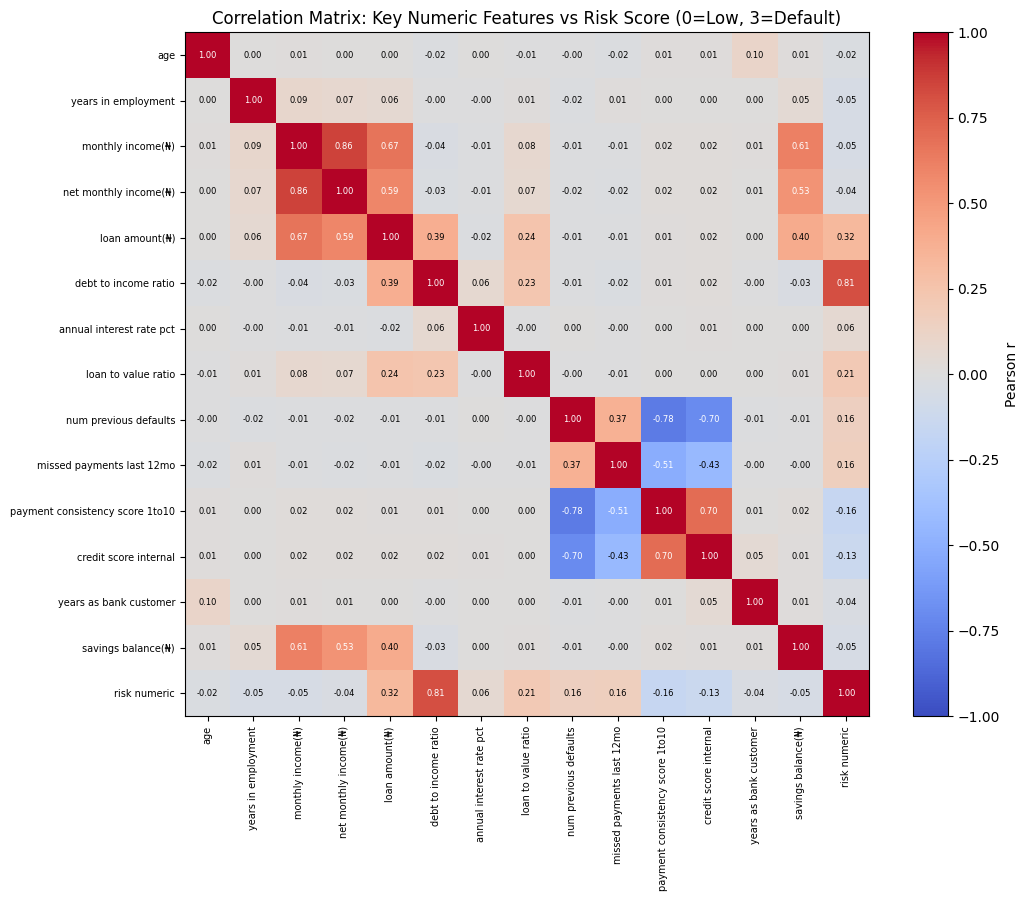

In [12]:
# Correlation heatmap — key numerics vs a numeric-encoded target
df["risk_numeric"] = df["loan_default_risk"].map(
    {"Low Risk": 0, "Medium Risk": 1, "High Risk": 2, "Default": 3}
)
corr_cols = ["tenure_corr" if c=="years_in_employment" else c for c in [
    "age","years_in_employment","monthly_income_naira","net_monthly_income_naira",
    "loan_amount_naira","debt_to_income_ratio","annual_interest_rate_pct",
    "loan_to_value_ratio","num_previous_defaults","missed_payments_last_12mo",
    "payment_consistency_score_1to10","credit_score_internal",
    "years_as_bank_customer","savings_balance_naira","risk_numeric"
]]
actual_cols = [c.replace("tenure_corr","years_in_employment") for c in corr_cols]
corr = df[actual_cols].corr()

plt.figure(figsize=(11, 9))
im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, label="Pearson r")
plt.xticks(range(len(actual_cols)), [c.replace("_naira","(₦)").replace("_"," ")
           for c in actual_cols], rotation=90, fontsize=7)
plt.yticks(range(len(actual_cols)), [c.replace("_naira","(₦)").replace("_"," ")
           for c in actual_cols], fontsize=7)
for i in range(len(actual_cols)):
    for j in range(len(actual_cols)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center",
                  color="white" if abs(corr.iloc[i,j]) > 0.5 else "black", fontsize=6)
plt.title("Correlation Matrix: Key Numeric Features vs Risk Score (0=Low, 3=Default)")
plt.tight_layout()
plt.show()

df.drop(columns=["risk_numeric"], inplace=True)


## 5. Data Cleaning: Imputing Missing Values

Five columns have small amounts of missing data (under 2% each). We use **median imputation** — same rationale as the churn notebook: robust to outliers, appropriate for such small missingness fractions.


In [13]:
df_clean = df.copy()

impute_cols = [
    "other_income_sources_naira",
    "property_value_naira",
    "previous_loan_completion_rate_pct",
    "days_overdue_on_previous",
    "payment_consistency_score_1to10",
]

for col in impute_cols:
    median_val = df_clean[col].median()
    n_miss = df_clean[col].isna().sum()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"{col:45s}: filled {n_miss:3d} NaNs  →  median = {median_val:,.2f}")

print(f"\nRemaining NaNs after imputation: {df_clean.isna().sum().sum()}")


other_income_sources_naira                   : filled 120 NaNs  →  median = 0.00
property_value_naira                         : filled 180 NaNs  →  median = 0.00
previous_loan_completion_rate_pct            : filled 100 NaNs  →  median = 99.70
days_overdue_on_previous                     : filled 150 NaNs  →  median = 0.00
payment_consistency_score_1to10              : filled  80 NaNs  →  median = 9.50

Remaining NaNs after imputation: 2504


## 6. Feature Engineering: Encoding and Derived Features

### 6.1 Derived Features

Before encoding, we engineer several new ratio/interaction features that compress domain knowledge into single numbers the model can use directly. These are standard practice in credit risk modelling.


In [14]:
# 6.1 Engineered ratio features
df_feat = df_clean.copy()

# Loan burden: what fraction of net monthly income goes to the loan installment
df_feat["installment_to_net_income"] = (
    df_feat["monthly_installment_naira"] /
    df_feat["net_monthly_income_naira"].replace(0, np.nan).fillna(1)
).clip(0, 10).round(4)

# Savings cushion: how many months of loan installments the applicant has saved
df_feat["savings_coverage_months"] = (
    df_feat["savings_balance_naira"] /
    df_feat["monthly_installment_naira"].replace(0, np.nan).fillna(1)
).clip(0, 120).round(2)

# Collateral coverage: collateral value as a fraction of the loan
df_feat["collateral_coverage_ratio"] = (
    df_feat["collateral_value_naira"] /
    df_feat["loan_amount_naira"].replace(0, np.nan).fillna(1)
).clip(0, 20).round(4)

# Default history burden: proportion of previous loans that defaulted
df_feat["default_rate_history"] = (
    df_feat["num_previous_defaults"] /
    df_feat["num_previous_loans"].replace(0, 1)
).clip(0, 1).round(4)

# Net worth proxy: savings + current account + property value
df_feat["net_worth_proxy_naira"] = (
    df_feat["savings_balance_naira"] +
    df_feat["current_account_balance_naira"] +
    df_feat["property_value_naira"]
)

print("Engineered features added:")
eng_feats = ["installment_to_net_income","savings_coverage_months",
             "collateral_coverage_ratio","default_rate_history","net_worth_proxy_naira"]
print(df_feat[eng_feats].describe().T[["mean","std","min","max"]].round(2).to_string())


Engineered features added:
                                 mean          std   min         max
installment_to_net_income        3.85         3.52  0.01        10.0
savings_coverage_months         17.79        27.38  0.00       120.0
collateral_coverage_ratio        2.98         5.46  0.00        20.0
default_rate_history             0.11         0.26  0.00         1.0
net_worth_proxy_naira      7288666.40  10463606.39  0.00  88207000.0


### 6.2 Encoding Categorical Variables and Preparing Arrays


In [15]:
# Drop the identifier column (carries no predictive value)
df_model = df_feat.drop(columns=["loan_id"])

# Identify categorical columns (excluding the target)
categorical_cols = df_model.select_dtypes(include="object").columns.tolist()
categorical_cols.remove("loan_default_risk")
numeric_cols     = df_model.select_dtypes(include=["int64","float64"]).columns.tolist()

print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"\nNumeric columns ({len(numeric_cols)}): {numeric_cols}")


Categorical columns (15): ['gender', 'marital_status', 'education_level', 'state', 'region', 'area_type', 'employment_type', 'employer_sector', 'owns_property', 'loan_purpose', 'collateral_type', 'bank_account_type', 'application_channel', 'guarantor_available', 'loan_officer_risk_rating']

Numeric columns (34): ['age', 'number_of_dependents', 'years_in_employment', 'monthly_income_naira', 'other_income_sources_naira', 'total_monthly_income_naira', 'monthly_expenses_naira', 'net_monthly_income_naira', 'savings_balance_naira', 'current_account_balance_naira', 'property_value_naira', 'loan_amount_naira', 'loan_term_months', 'annual_interest_rate_pct', 'monthly_installment_naira', 'debt_to_income_ratio', 'collateral_value_naira', 'loan_to_value_ratio', 'years_as_bank_customer', 'avg_monthly_transactions', 'avg_monthly_credit_naira', 'avg_monthly_debit_naira', 'num_previous_loans', 'num_previous_defaults', 'previous_loan_completion_rate_pct', 'missed_payments_last_12mo', 'days_overdue_on_p

In [16]:
# One-hot encoding of all categorical columns
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=False)

print(f"Shape before encoding: {df_model.shape}")
print(f"Shape after encoding : {df_encoded.shape}")
print(f"New columns added by encoding: {df_encoded.shape[1] - df_model.shape[1]}")


Shape before encoding: (10000, 50)
Shape after encoding : (10000, 117)
New columns added by encoding: 67


In [17]:
# Encode target as integer class indices for CrossEntropyLoss
label_to_idx = {"Low Risk": 0, "Medium Risk": 1, "High Risk": 2, "Default": 3}
idx_to_label = {v: k for k, v in label_to_idx.items()}

y = df_encoded["loan_default_risk"].map(label_to_idx).values.astype(np.int64)
X = df_encoded.drop(columns=["loan_default_risk"]).astype(np.float32)

feature_names = X.columns.tolist()
print(f"Feature matrix shape  : {X.shape}")
print(f"Label array shape     : {y.shape}")
print(f"Label distribution    : {dict(zip(*np.unique(y, return_counts=True)))}")
print(f"  (0=Low Risk, 1=Medium Risk, 2=High Risk, 3=Default)")


Feature matrix shape  : (10000, 116)
Label array shape     : (10000,)
Label distribution    : {np.int64(0): np.int64(3500), np.int64(1): np.int64(3000), np.int64(2): np.int64(2300), np.int64(3): np.int64(1200)}
  (0=Low Risk, 1=Medium Risk, 2=High Risk, 3=Default)


## 7. Stratified Train / Validation / Test Split

Three-way split with stratification across all four classes — critical here because the Default class is the smallest (12%) and we must ensure it is proportionally represented in training, validation, and test sets.


In [18]:
# 70% train | 15% val | 15% test — all stratified
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"Training set:   {X_train.shape[0]:,} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]:,} ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:       {X_test.shape[0]:,} ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verify class balance in each split
for name, labels in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    unique, counts = np.unique(labels, return_counts=True)
    pcts = counts / counts.sum() * 100
    breakdown = " | ".join([f"{CLASSES[u]}: {p:.1f}%" for u, p in zip(unique, pcts)])
    print(f"{name:5s}: {breakdown}")


Training set:   7,000 (70.0%)
Validation set: 1,500 (15.0%)
Test set:       1,500 (15.0%)
Train: Low Risk: 35.0% | Medium Risk: 30.0% | High Risk: 23.0% | Default: 12.0%
Val  : Low Risk: 35.0% | Medium Risk: 30.0% | High Risk: 23.0% | Default: 12.0%
Test : Low Risk: 35.0% | Medium Risk: 30.0% | High Risk: 23.0% | Default: 12.0%


## 8. Feature Scaling


In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Scaling applied. First 5 features of training data:")
print(f"  mean: {X_train_scaled.mean(axis=0)[:5].round(4)}")
print(f"  std : {X_train_scaled.std(axis=0)[:5].round(4)}")
print(f"\nTotal features going into the model: {X_train_scaled.shape[1]}")


Scaling applied. First 5 features of training data:
  mean: [ 0. -0. -0.  0.  0.]
  std : [1. 1. 1. 1. 1.]

Total features going into the model: 116


## 9. PyTorch Dataset and DataLoader

One important difference from the binary classifier: labels are now **integer class indices** (`0, 1, 2, 3`) stored as `torch.long` tensors rather than float32 values — this is what `nn.CrossEntropyLoss` expects as targets.


In [20]:
class LoanRiskDataset(Dataset):
    """Wraps scaled feature arrays and integer class labels for DataLoader."""
    def __init__(self, features, labels):
        self.X = torch.tensor(features, dtype=torch.float32)
        self.y = torch.tensor(labels,   dtype=torch.long)   # CrossEntropyLoss needs long int

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 128  # larger batch than churn project given 10k samples

train_loader = DataLoader(LoanRiskDataset(X_train_scaled, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(LoanRiskDataset(X_val_scaled,   y_val),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(LoanRiskDataset(X_test_scaled,  y_test),  batch_size=BATCH_SIZE, shuffle=False)

print(f"Training batches:   {len(train_loader)}  ({len(train_loader.dataset):,} samples)")
print(f"Validation batches: {len(val_loader)}  ({len(val_loader.dataset):,} samples)")
print(f"Test batches:       {len(test_loader)}  ({len(test_loader.dataset):,} samples)")

# Confirm shape
sample_X, sample_y = next(iter(train_loader))
print(f"\nBatch X shape: {sample_X.shape}   (batch_size, n_features)")
print(f"Batch y shape: {sample_y.shape}   (batch_size,)  — integer class indices")
INPUT_DIM = sample_X.shape[1]
print(f"INPUT_DIM = {INPUT_DIM}")


Training batches:   55  (7,000 samples)
Validation batches: 12  (1,500 samples)
Test batches:       12  (1,500 samples)

Batch X shape: torch.Size([128, 116])   (batch_size, n_features)
Batch y shape: torch.Size([128])   (batch_size,)  — integer class indices
INPUT_DIM = 116


## 10. Defining the Multi-Class Risk Classifier

### 10.1 Architecture

This network is deeper than the churn model — `INPUT_DIM → 128 → 64 → 32 → 16 → 4` — reflecting the larger feature space (more input dimensions need more initial compression capacity) and a more complex decision boundary separating four ordered classes rather than two.

### 10.2 Key Differences From the Binary Churn Classifier

| Aspect | Binary Churn Model | 4-Class Loan Risk Model |
|---|---|---|
| Output neurons | 1 (raw logit) | 4 (one logit per class) |
| Final activation | None (BCEWithLogitsLoss applies sigmoid internally) | None (CrossEntropyLoss applies Softmax internally) |
| Loss function | `nn.BCEWithLogitsLoss` | `nn.CrossEntropyLoss` |
| Label format | `float32` tensor of 0.0/1.0 | `long` (int64) tensor of class index 0/1/2/3 |
| Prediction step | `sigmoid(logit) >= 0.5` | `argmax(softmax(logits))` |

### 10.3 Batch Normalisation

We introduce `nn.BatchNorm1d` here — another layer type not used in the earlier masterclass. BatchNorm normalises each mini-batch's activations to have mean 0 and standard deviation 1 before passing them to the next layer, stabilising training and often allowing higher learning rates. Like Dropout, it behaves differently during `model.train()` and `model.eval()` — in eval mode it uses running statistics accumulated during training rather than per-batch statistics.


In [21]:
class LoanRiskClassifier(nn.Module):
    def __init__(self, input_dim, h1=128, h2=64, h3=32, h4=16, dropout_p=0.30):
        super().__init__()

        # Layer 1: input → h1
        self.layer1 = nn.Linear(input_dim, h1)
        self.bn1    = nn.BatchNorm1d(h1)

        # Layer 2: h1 → h2
        self.layer2 = nn.Linear(h1, h2)
        self.bn2    = nn.BatchNorm1d(h2)

        # Layer 3: h2 → h3
        self.layer3 = nn.Linear(h2, h3)
        self.bn3    = nn.BatchNorm1d(h3)

        # Layer 4: h3 → h4
        self.layer4 = nn.Linear(h3, h4)

        # Output layer: h4 → 4 classes (raw logits, no softmax)
        self.output_layer = nn.Linear(h4, NUM_CLASSES)

        self.dropout = nn.Dropout(dropout_p)

    def forward(self, x):
        x = self.dropout(F.relu(self.bn1(self.layer1(x))))
        x = self.dropout(F.relu(self.bn2(self.layer2(x))))
        x = self.dropout(F.relu(self.bn3(self.layer3(x))))
        x = F.relu(self.layer4(x))             # no dropout before the final squeeze
        x = self.output_layer(x)               # raw logits, shape (batch_size, 4)
        return x


torch.manual_seed(SEED)
model = LoanRiskClassifier(input_dim=INPUT_DIM).to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {total_params:,}")


LoanRiskClassifier(
  (layer1): Linear(in_features=116, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (layer2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (layer3): Linear(in_features=64, out_features=32, bias=True)
  (bn3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (layer4): Linear(in_features=32, out_features=16, bias=True)
  (output_layer): Linear(in_features=16, out_features=4, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

Total trainable parameters: 26,356


## 11. Loss Function, Class Weights, and Optimizer

### 11.1 Class Weights for `nn.CrossEntropyLoss`

Just as `pos_weight` rebalanced the binary churn model, `weight` rebalances the multi-class loss. The standard approach is to set each class's weight proportional to the **inverse of its frequency** — the rarest class (Default at 12%) gets the highest weight, making the model pay more attention to correctly classifying Default applicants.

The formula used is: `weight_i = N / (num_classes × count_i)` where N is the total training sample count.


In [22]:
# Compute per-class weights from training label distribution
class_counts = np.bincount(y_train, minlength=NUM_CLASSES)
class_weights = len(y_train) / (NUM_CLASSES * class_counts)
class_weight_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Training class distribution and weights:")
print("-"*55)
for i, (cls, cnt, wt) in enumerate(zip(CLASSES, class_counts, class_weights)):
    print(f"  Class {i} ({cls:<15}): {cnt:>5} samples  →  weight = {wt:.4f}")
print(f"\nWeights vector: {class_weight_tensor.numpy().round(4)}")

loss_fn = nn.CrossEntropyLoss(weight=class_weight_tensor)

optimizer = torch.optim.Adam(
    model.parameters(), lr=0.001, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
print("\nOptimizer: Adam  lr=0.001  weight_decay=1e-4")
print("LR Scheduler: StepLR — halves learning rate every 20 epochs")


Training class distribution and weights:
-------------------------------------------------------
  Class 0 (Low Risk       ):  2450 samples  →  weight = 0.7143
  Class 1 (Medium Risk    ):  2100 samples  →  weight = 0.8333
  Class 2 (High Risk      ):  1610 samples  →  weight = 1.0870
  Class 3 (Default        ):   840 samples  →  weight = 2.0833

Weights vector: [0.7143 0.8333 1.087  2.0833]



Optimizer: Adam  lr=0.001  weight_decay=1e-4
LR Scheduler: StepLR — halves learning rate every 20 epochs


## 12. Training Loop with Validation, Early Stopping, and LR Scheduling


In [23]:
def run_epoch_multiclass(loader, model, loss_fn, optimizer=None):
    """
    Unified training/evaluation function for multi-class classification.
    optimizer=None  → evaluation mode (no weight updates, no gradient computation).
    optimizer given → training mode (forward, loss, backward, update).
    """
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    context = torch.enable_grad() if is_training else torch.no_grad()

    with context:
        for batch_X, batch_y in loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            logits = model(batch_X)                      # shape: (batch_size, 4)
            loss   = loss_fn(logits, batch_y)            # CrossEntropyLoss expects (N,C) logits and (N,) labels

            if is_training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            preds   = logits.argmax(dim=1)               # class with highest logit = prediction
            correct += (preds == batch_y).sum().item()
            total   += batch_y.size(0)
            total_loss += loss.item() * batch_y.size(0)

    return total_loss / total, correct / total


In [24]:
NUM_EPOCHS = 120
PATIENCE   = 18    # early stop if val loss doesn't improve for 18 consecutive epochs

train_loss_hist, train_acc_hist = [], []
val_loss_hist,   val_acc_hist   = [], []

best_val_loss   = float("inf")
no_improve      = 0
best_state      = None

print(f"{'Epoch':>6}  {'Train Loss':>11}  {'Train Acc':>10}  {'Val Loss':>10}  {'Val Acc':>9}  {'LR':>10}")
print("-" * 65)

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = run_epoch_multiclass(train_loader, model, loss_fn, optimizer)
    val_loss,   val_acc   = run_epoch_multiclass(val_loader,   model, loss_fn, optimizer=None)

    train_loss_hist.append(train_loss)
    train_acc_hist.append(train_acc)
    val_loss_hist.append(val_loss)
    val_acc_hist.append(val_acc)

    current_lr = optimizer.param_groups[0]["lr"]
    scheduler.step()          # step the LR scheduler every epoch

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve    = 0
        best_state    = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        no_improve += 1

    if epoch % 6 == 0 or epoch == NUM_EPOCHS - 1:
        print(f"{epoch:>6}  {train_loss:>11.4f}  {train_acc*100:>9.2f}%  "
              f"{val_loss:>10.4f}  {val_acc*100:>8.2f}%  {current_lr:>10.6f}")

    if no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} — no validation improvement for {PATIENCE} epochs.")
        break

model.load_state_dict(best_state)
print(f"\nBest model restored (val loss = {best_val_loss:.4f})")


 Epoch   Train Loss   Train Acc    Val Loss    Val Acc          LR
-----------------------------------------------------------------


     0       1.3531      37.10%      1.2548     52.27%    0.001000


     6       0.7455      62.71%      0.7275     63.40%    0.001000


    12       0.6773      66.59%      0.7384     64.73%    0.001000


    18       0.6298      68.80%      0.7419     64.40%    0.001000


    24       0.6003      70.71%      0.7713     64.60%    0.000500



Early stopping at epoch 26 — no validation improvement for 18 epochs.

Best model restored (val loss = 0.7223)


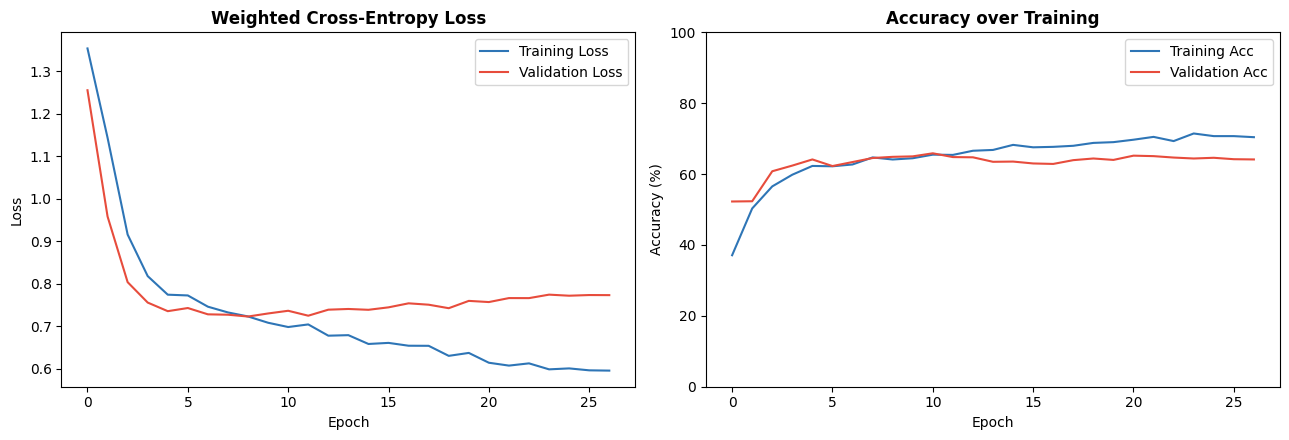

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(train_loss_hist, label="Training Loss",   color="#2E75B6")
axes[0].plot(val_loss_hist,   label="Validation Loss", color="#E74C3C")
axes[0].set_title("Weighted Cross-Entropy Loss", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot([a*100 for a in train_acc_hist], label="Training Acc",   color="#2E75B6")
axes[1].plot([a*100 for a in val_acc_hist],   label="Validation Acc", color="#E74C3C")
axes[1].set_title("Accuracy over Training",   fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_ylim(0, 100)
axes[1].legend()

plt.tight_layout()
plt.show()


## 13. Comprehensive Test-Set Evaluation

### 13.1 Collect All Predictions


In [26]:
model.eval()
all_logits, all_labels = [], []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        logits = model(batch_X.to(device)).cpu()
        all_logits.append(logits)
        all_labels.append(batch_y)

all_logits = torch.cat(all_logits)                           # (N_test, 4)
all_labels = torch.cat(all_labels)                           # (N_test,)
all_probs  = F.softmax(all_logits, dim=1).numpy()           # (N_test, 4) probability per class
all_preds  = all_logits.argmax(dim=1).numpy()               # (N_test,)  predicted class index
y_true     = all_labels.numpy()

print(f"Test set size: {len(y_true):,}")
print("Class distribution in test set:")
for i, cls in enumerate(CLASSES):
    cnt = (y_true == i).sum()
    print(f"  {cls:<15}: {cnt:>4} ({cnt/len(y_true)*100:.1f}%)")


Test set size: 1,500
Class distribution in test set:
  Low Risk       :  525 (35.0%)
  Medium Risk    :  450 (30.0%)
  High Risk      :  345 (23.0%)
  Default        :  180 (12.0%)


### 13.2 Overall Metrics


In [27]:
acc  = accuracy_score(y_true, all_preds)
prec = precision_score(y_true, all_preds, average="macro",    zero_division=0)
rec  = recall_score(   y_true, all_preds, average="macro",    zero_division=0)
f1   = f1_score(       y_true, all_preds, average="macro",    zero_division=0)
wf1  = f1_score(       y_true, all_preds, average="weighted", zero_division=0)

print("=" * 60)
print("OVERALL TEST SET PERFORMANCE")
print("=" * 60)
print(f"Accuracy          : {acc*100:.2f}%")
print(f"Macro Precision   : {prec*100:.2f}%  (unweighted avg across 4 classes)")
print(f"Macro Recall      : {rec*100:.2f}%  (unweighted avg across 4 classes)")
print(f"Macro F1-Score    : {f1*100:.2f}%  (unweighted avg — every class counts equally)")
print(f"Weighted F1-Score : {wf1*100:.2f}%  (weighted by class support)")
print()
print(classification_report(y_true, all_preds, target_names=CLASSES))


OVERALL TEST SET PERFORMANCE
Accuracy          : 64.00%
Macro Precision   : 63.36%  (unweighted avg across 4 classes)
Macro Recall      : 67.23%  (unweighted avg across 4 classes)
Macro F1-Score    : 64.63%  (unweighted avg — every class counts equally)
Weighted F1-Score : 62.69%  (weighted by class support)

              precision    recall  f1-score   support

    Low Risk       0.71      0.80      0.75       525
 Medium Risk       0.53      0.38      0.44       450
   High Risk       0.58      0.59      0.58       345
     Default       0.72      0.92      0.81       180

    accuracy                           0.64      1500
   macro avg       0.63      0.67      0.65      1500
weighted avg       0.63      0.64      0.63      1500



### 13.3 The 4×4 Confusion Matrix

A 4×4 confusion matrix is the richest diagnostic for a multi-class classifier: the diagonal shows correct predictions, and off-diagonal cells reveal the *type* of error — whether the model confuses Low Risk with Medium Risk (a mild, adjacent error) or Low Risk with Default (a severe, non-adjacent error).


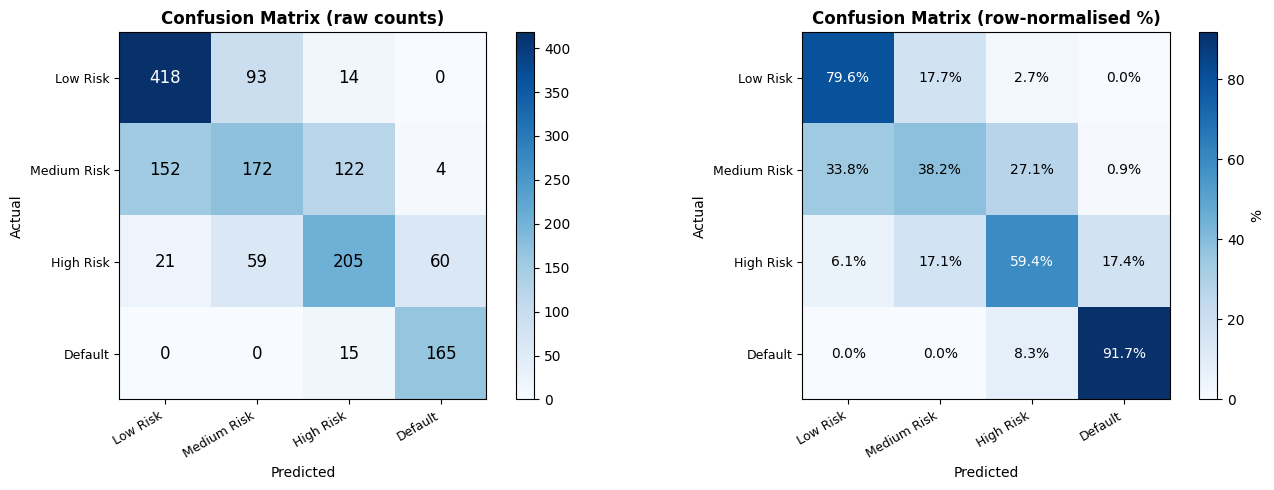


Diagonal (correctly classified):
  Low Risk       :  418 / 525 (79.6%) correctly identified
  Medium Risk    :  172 / 450 (38.2%) correctly identified
  High Risk      :  205 / 345 (59.4%) correctly identified
  Default        :  165 / 180 (91.7%) correctly identified

Most common misclassification per class:
  Low Risk        → most often confused with 'Medium Risk' (93 times)
  Medium Risk     → most often confused with 'Low Risk' (152 times)
  High Risk       → most often confused with 'Default' (60 times)
  Default         → most often confused with 'High Risk' (15 times)


In [28]:
cm = confusion_matrix(y_true, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
im = axes[0].imshow(cm, cmap="Blues")
plt.colorbar(im, ax=axes[0])
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, str(cm[i,j]), ha="center", va="center", fontsize=12,
                      color="white" if cm[i,j] > cm.max()/2 else "black")
axes[0].set_xticks(range(4)); axes[0].set_yticks(range(4))
axes[0].set_xticklabels(CLASSES, rotation=30, ha="right", fontsize=9)
axes[0].set_yticklabels(CLASSES, fontsize=9)
axes[0].set_xlabel("Predicted", fontsize=10); axes[0].set_ylabel("Actual", fontsize=10)
axes[0].set_title("Confusion Matrix (raw counts)", fontweight="bold")

# Percentages (row-normalised)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
im2 = axes[1].imshow(cm_pct, cmap="Blues")
plt.colorbar(im2, ax=axes[1], label="%")
for i in range(4):
    for j in range(4):
        axes[1].text(j, i, f"{cm_pct[i,j]:.1f}%", ha="center", va="center", fontsize=10,
                      color="white" if cm_pct[i,j] > 50 else "black")
axes[1].set_xticks(range(4)); axes[1].set_yticks(range(4))
axes[1].set_xticklabels(CLASSES, rotation=30, ha="right", fontsize=9)
axes[1].set_yticklabels(CLASSES, fontsize=9)
axes[1].set_xlabel("Predicted", fontsize=10); axes[1].set_ylabel("Actual", fontsize=10)
axes[1].set_title("Confusion Matrix (row-normalised %)", fontweight="bold")

plt.tight_layout()
plt.show()

# Text summary
print("\nDiagonal (correctly classified):")
for i, cls in enumerate(CLASSES):
    total_in_class = cm[i].sum()
    print(f"  {cls:<15}: {cm[i,i]:>4} / {total_in_class} ({cm[i,i]/total_in_class*100:.1f}%) correctly identified")

print("\nMost common misclassification per class:")
for i, cls in enumerate(CLASSES):
    off_diag = cm[i].copy(); off_diag[i] = 0
    worst_j = off_diag.argmax()
    if off_diag[worst_j] > 0:
        print(f"  {cls:<15} → most often confused with '{CLASSES[worst_j]}' ({cm[i,worst_j]} times)")


## 14. One-vs-Rest ROC Curves and AUC Scores

For a multi-class problem, we compute one ROC curve per class using the **One-vs-Rest (OvR)** strategy: for class k, we treat all k-class samples as "positive" and all other samples as "negative", then plot the ROC curve using the model's predicted probability for class k as the score.


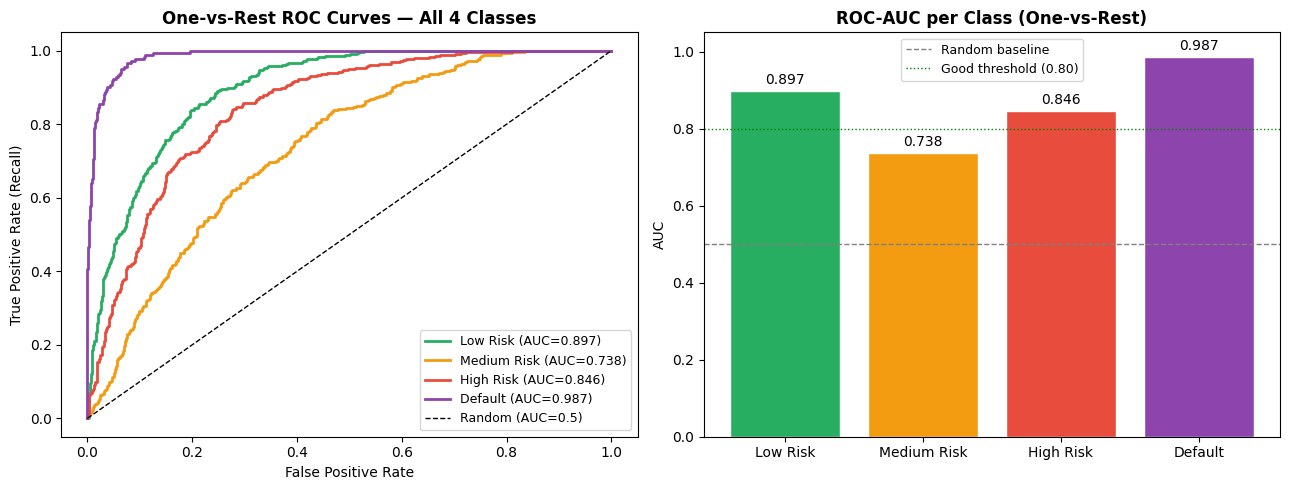

Macro-average ROC-AUC (all 4 classes combined): 0.8669

Per-class AUC:
  Low Risk       : 0.8970
  Medium Risk    : 0.7375
  High Risk      : 0.8463
  Default        : 0.9869


In [29]:
# Binarize labels for OvR ROC computation
y_bin = label_binarize(y_true, classes=[0, 1, 2, 3])  # shape (N_test, 4)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

auc_scores = {}
for i, (cls, col) in enumerate(zip(CLASSES, CLASS_COLORS)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    auc_val = roc_auc_score(y_bin[:, i], all_probs[:, i])
    auc_scores[cls] = auc_val
    axes[0].plot(fpr, tpr, color=col, linewidth=2, label=f"{cls} (AUC={auc_val:.3f})")

axes[0].plot([0,1],[0,1], "k--", linewidth=1, label="Random (AUC=0.5)")
axes[0].set_title("One-vs-Rest ROC Curves — All 4 Classes", fontweight="bold")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate (Recall)")
axes[0].legend(fontsize=9)

# AUC bar chart
bars = axes[1].bar(CLASSES, list(auc_scores.values()), color=CLASS_COLORS, edgecolor="white")
axes[1].axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Random baseline")
axes[1].axhline(0.8, color="green",  linestyle=":",  linewidth=1, label="Good threshold (0.80)")
axes[1].set_ylim(0, 1.05)
axes[1].set_title("ROC-AUC per Class (One-vs-Rest)", fontweight="bold")
axes[1].set_ylabel("AUC")
for bar, v in zip(bars, auc_scores.values()):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                  f"{v:.3f}", ha="center", va="bottom", fontsize=10)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

macro_auc = roc_auc_score(y_bin, all_probs, average="macro")
print(f"Macro-average ROC-AUC (all 4 classes combined): {macro_auc:.4f}")
print("\nPer-class AUC:")
for cls, val in auc_scores.items():
    print(f"  {cls:<15}: {val:.4f}")


## 15. Per-Class Probability Distributions

Visualising the model's predicted probability distributions for each class helps understand whether the model is well-calibrated and confident, or uncertain and "soft" across all four classes.


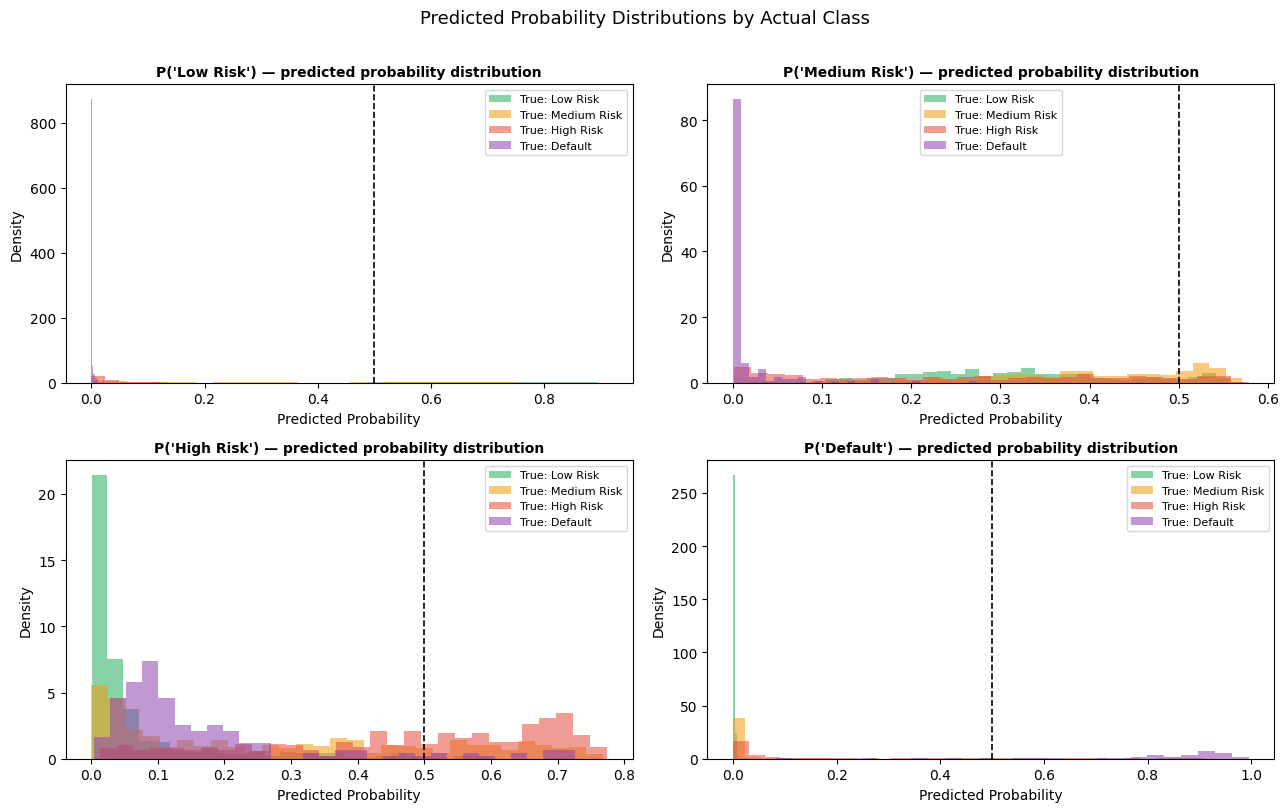

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, (cls, col) in enumerate(zip(CLASSES, CLASS_COLORS)):
    for j, (actual_cls, actual_col) in enumerate(zip(CLASSES, CLASS_COLORS)):
        mask = (y_true == j)
        axes[i].hist(all_probs[mask, i], bins=30, alpha=0.55, color=actual_col,
                      label=f"True: {actual_cls}", density=True)
    axes[i].axvline(0.5, color="black", linestyle="--", linewidth=1.2)
    axes[i].set_title(f"P('{cls}') — predicted probability distribution", fontsize=10, fontweight="bold")
    axes[i].set_xlabel("Predicted Probability")
    axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=8)

plt.suptitle("Predicted Probability Distributions by Actual Class", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()


## 16. Feature Importance via Permutation

Using the same permutation-importance technique as the churn notebook — for each of the 82 one-hot encoded features, we shuffle its values and measure the drop in macro-AUC.


In [31]:
def model_macro_auc(X_arr, y_arr):
    """Compute macro-average OvR AUC of the model on a numpy feature array."""
    model.eval()
    with torch.no_grad():
        probs = F.softmax(
            model(torch.tensor(X_arr, dtype=torch.float32).to(device)).cpu(), dim=1
        ).numpy()
    y_bin_arr = label_binarize(y_arr, classes=[0,1,2,3])
    return roc_auc_score(y_bin_arr, probs, average="macro")

baseline_auc = model_macro_auc(X_test_scaled, y_test)
print(f"Baseline macro-AUC: {baseline_auc:.4f}")

rng_imp = np.random.default_rng(SEED)
importance_results = []

for i, fname in enumerate(feature_names):
    X_shuf = X_test_scaled.copy()
    rng_imp.shuffle(X_shuf[:, i])
    drop = baseline_auc - model_macro_auc(X_shuf, y_test)
    importance_results.append({"feature": fname, "importance": drop})

imp_df = pd.DataFrame(importance_results).sort_values("importance", ascending=False)
print(f"Permutation importance computed for all {len(feature_names)} features.")


Baseline macro-AUC: 0.8669


Permutation importance computed for all 116 features.


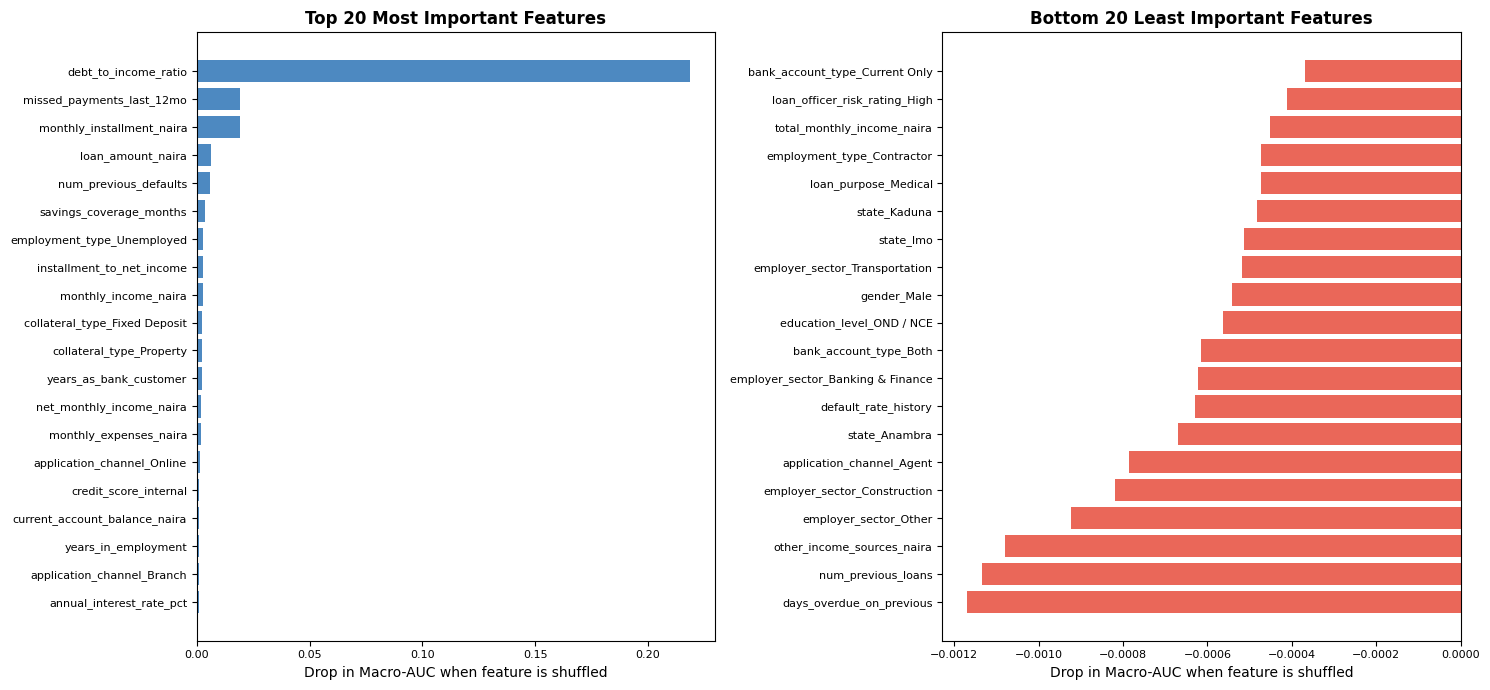


Top 20 most important features:
                      feature  importance
         debt_to_income_ratio    0.218869
    missed_payments_last_12mo    0.019258
    monthly_installment_naira    0.019070
            loan_amount_naira    0.006487
        num_previous_defaults    0.005746
      savings_coverage_months    0.003424
   employment_type_Unemployed    0.002912
    installment_to_net_income    0.002784
         monthly_income_naira    0.002610
collateral_type_Fixed Deposit    0.002329
     collateral_type_Property    0.002274
       years_as_bank_customer    0.002193
     net_monthly_income_naira    0.001872
       monthly_expenses_naira    0.001711
   application_channel_Online    0.001413
        credit_score_internal    0.001022
current_account_balance_naira    0.001013
          years_in_employment    0.000976
   application_channel_Branch    0.000969
     annual_interest_rate_pct    0.000914


In [32]:
top_n = 20
top_imp = imp_df.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Top features bar
axes[0].barh(top_imp["feature"][::-1], top_imp["importance"][::-1], color="#2E75B6", alpha=0.85)
axes[0].set_xlabel("Drop in Macro-AUC when feature is shuffled")
axes[0].set_title(f"Top {top_n} Most Important Features", fontweight="bold")
axes[0].tick_params(labelsize=8)

# Bottom features bar (near-zero importance)
bottom_imp = imp_df.tail(20)
axes[1].barh(bottom_imp["feature"][::-1], bottom_imp["importance"][::-1], color="#E74C3C", alpha=0.85)
axes[1].set_xlabel("Drop in Macro-AUC when feature is shuffled")
axes[1].set_title("Bottom 20 Least Important Features", fontweight="bold")
axes[1].tick_params(labelsize=8)

plt.tight_layout()
plt.show()

print("\nTop 20 most important features:")
print(top_imp.to_string(index=False))


## 17. Scoring a New Loan Application

The `predict_loan_risk()` function reproduces the complete preprocessing pipeline on a single raw loan application dictionary and returns the predicted risk class, probability breakdown per class, and a recommended action.


In [33]:
def predict_loan_risk(application_dict, verbose=True):
    """
    Runs a raw loan application dictionary through the complete preprocessing pipeline
    and returns a risk assessment.

    Parameters
    ----------
    application_dict : dict  — raw applicant fields matching original dataset columns
                               (excluding loan_id and loan_default_risk)
    verbose          : bool  — if True, prints a formatted risk report

    Returns
    -------
    dict with keys: predicted_class (int), predicted_label (str), probabilities (list),
                    recommended_action (str)
    """
    # 1. Wrap in DataFrame
    app_df = pd.DataFrame([application_dict])

    # 2. Engineered features (replicate the same transformations as training)
    app_df["installment_to_net_income"] = (
        app_df["monthly_installment_naira"] /
        app_df["net_monthly_income_naira"].replace(0, np.nan).fillna(1)
    ).clip(0, 10)
    app_df["savings_coverage_months"] = (
        app_df["savings_balance_naira"] /
        app_df["monthly_installment_naira"].replace(0, np.nan).fillna(1)
    ).clip(0, 120)
    app_df["collateral_coverage_ratio"] = (
        app_df["collateral_value_naira"] /
        app_df["loan_amount_naira"].replace(0, np.nan).fillna(1)
    ).clip(0, 20)
    app_df["default_rate_history"] = (
        app_df["num_previous_defaults"] /
        app_df["num_previous_loans"].replace(0, 1)
    ).clip(0, 1)
    app_df["net_worth_proxy_naira"] = (
        app_df["savings_balance_naira"] +
        app_df["current_account_balance_naira"] +
        app_df["property_value_naira"]
    )

    # 3. One-hot encode (same categorical columns as training)
    app_encoded = pd.get_dummies(app_df, columns=categorical_cols, drop_first=False)

    # 4. Align to training feature schema
    app_aligned = app_encoded.reindex(columns=feature_names, fill_value=0).astype(np.float32)

    # 5. Scale with the fitted scaler
    app_scaled = scaler.transform(app_aligned)

    # 6. Run model
    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(app_scaled, dtype=torch.float32).to(device))
        probs  = F.softmax(logits, dim=1).cpu().numpy()[0]
        pred_class = int(probs.argmax())

    pred_label = CLASSES[pred_class]
    actions = {
        "Low Risk":    "APPROVE at standard terms and rate.",
        "Medium Risk": "APPROVE with enhanced monitoring and quarterly review.",
        "High Risk":   "CONDITIONAL APPROVAL — require additional collateral or senior guarantor.",
        "Default":     "DECLINE — refer to credit restructuring team.",
    }

    if verbose:
        print("=" * 58)
        print("LOAN DEFAULT RISK ASSESSMENT")
        print("=" * 58)
        print(f"  Predicted Risk Class  : {pred_label}")
        print(f"  Recommended Action    : {actions[pred_label]}")
        print()
        print("  Probability Breakdown:")
        for cls, prob, col_name in zip(CLASSES, probs, CLASS_COLORS):
            bar_len = int(prob * 30)
            marker  = " ◄ PREDICTED" if cls == pred_label else ""
            print(f"    {cls:<15}: {prob*100:5.1f}%  {'█'*bar_len}{marker}")
        print("=" * 58)

    return {
        "predicted_class":     pred_class,
        "predicted_label":     pred_label,
        "probabilities":       probs.tolist(),
        "recommended_action":  actions[pred_label],
    }


# ---- Example 1: A strong applicant ----
strong_applicant = {
    "gender": "Male", "age": 42, "marital_status": "Married",
    "education_level": "HND / B.Sc", "state": "Lagos",
    "region": "South West", "area_type": "Urban",
    "number_of_dependents": 2, "employment_type": "Salaried",
    "employer_sector": "Banking & Finance", "years_in_employment": 12,
    "monthly_income_naira": 450_000, "other_income_sources_naira": 80_000,
    "total_monthly_income_naira": 530_000, "monthly_expenses_naira": 210_000,
    "net_monthly_income_naira": 320_000, "savings_balance_naira": 5_200_000,
    "current_account_balance_naira": 1_800_000, "owns_property": "Yes",
    "property_value_naira": 35_000_000, "loan_purpose": "Home Purchase",
    "loan_amount_naira": 12_000_000, "loan_term_months": 60,
    "annual_interest_rate_pct": 16.5, "monthly_installment_naira": 295_000,
    "debt_to_income_ratio": 55.7, "collateral_type": "Property",
    "collateral_value_naira": 35_000_000, "loan_to_value_ratio": 34.3,
    "bank_account_type": "Both", "years_as_bank_customer": 14,
    "avg_monthly_transactions": 35, "avg_monthly_credit_naira": 500_000,
    "avg_monthly_debit_naira": 220_000, "application_channel": "Branch",
    "guarantor_available": "Yes", "num_previous_loans": 3,
    "num_previous_defaults": 0, "previous_loan_completion_rate_pct": 100.0,
    "missed_payments_last_12mo": 0, "days_overdue_on_previous": 0,
    "payment_consistency_score_1to10": 9.8, "credit_score_internal": 795,
    "loan_officer_risk_rating": "Low",
}

print("\n--- APPLICANT 1: Strong Financial Profile ---")
result1 = predict_loan_risk(strong_applicant)



--- APPLICANT 1: Strong Financial Profile ---
LOAN DEFAULT RISK ASSESSMENT
  Predicted Risk Class  : Low Risk
  Recommended Action    : APPROVE at standard terms and rate.

  Probability Breakdown:
    Low Risk       :  50.1%  ███████████████ ◄ PREDICTED
    Medium Risk    :  41.9%  ████████████
    High Risk      :   7.8%  ██
    Default        :   0.2%  


In [34]:
# ---- Example 2: A high-risk applicant ----
risky_applicant = {
    "gender": "Female", "age": 29, "marital_status": "Single",
    "education_level": "Secondary / O-Level", "state": "Kano",
    "region": "North West", "area_type": "Rural",
    "number_of_dependents": 5, "employment_type": "Self-Employed",
    "employer_sector": "Trading", "years_in_employment": 1.5,
    "monthly_income_naira": 65_000, "other_income_sources_naira": 0,
    "total_monthly_income_naira": 65_000, "monthly_expenses_naira": 58_000,
    "net_monthly_income_naira": 7_000, "savings_balance_naira": 45_000,
    "current_account_balance_naira": 12_000, "owns_property": "No",
    "property_value_naira": 0, "loan_purpose": "Debt Consolidation",
    "loan_amount_naira": 1_800_000, "loan_term_months": 24,
    "annual_interest_rate_pct": 32.0, "monthly_installment_naira": 105_000,
    "debt_to_income_ratio": 161.5, "collateral_type": "None",
    "collateral_value_naira": 0, "loan_to_value_ratio": 200.0,
    "bank_account_type": "Savings Only", "years_as_bank_customer": 1,
    "avg_monthly_transactions": 6, "avg_monthly_credit_naira": 62_000,
    "avg_monthly_debit_naira": 59_000, "application_channel": "Agent",
    "guarantor_available": "No", "num_previous_loans": 2,
    "num_previous_defaults": 2, "previous_loan_completion_rate_pct": 0.0,
    "missed_payments_last_12mo": 7, "days_overdue_on_previous": 145,
    "payment_consistency_score_1to10": 2.1, "credit_score_internal": 355,
    "loan_officer_risk_rating": "High",
}

print("\n--- APPLICANT 2: High-Risk Profile ---")
result2 = predict_loan_risk(risky_applicant)



--- APPLICANT 2: High-Risk Profile ---
LOAN DEFAULT RISK ASSESSMENT
  Predicted Risk Class  : Default
  Recommended Action    : DECLINE — refer to credit restructuring team.

  Probability Breakdown:
    Low Risk       :   0.0%  
    Medium Risk    :   0.0%  
    High Risk      :   1.9%  
    Default        :  98.1%  █████████████████████████████ ◄ PREDICTED


## 18. Saving the Model and Preprocessing Pipeline


In [35]:
import os, pickle

os.makedirs("saved_models", exist_ok=True)

# 1. Model weights
torch.save(model.state_dict(), "saved_models/loan_risk_classifier.pth")

# 2. Full preprocessing pipeline
pipeline_dict = {
    "scaler":          scaler,
    "feature_names":   feature_names,
    "categorical_cols": categorical_cols,
    "label_to_idx":    label_to_idx,
    "idx_to_label":    idx_to_label,
    "classes":         CLASSES,
    "model_config": {
        "input_dim": INPUT_DIM,
        "h1": 128, "h2": 64, "h3": 32, "h4": 16, "dropout_p": 0.30
    },
}
with open("saved_models/loan_preprocessing.pkl", "wb") as f:
    pickle.dump(pipeline_dict, f)

print("Files saved:")
for fname in ["loan_risk_classifier.pth", "loan_preprocessing.pkl"]:
    sz = os.path.getsize(f"saved_models/{fname}")
    print(f"  saved_models/{fname}  ({sz:,} bytes)")


Files saved:
  saved_models/loan_risk_classifier.pth  (115,691 bytes)
  saved_models/loan_preprocessing.pkl  (6,960 bytes)


In [36]:
# Full round-trip verification
with open("saved_models/loan_preprocessing.pkl", "rb") as f:
    loaded_pipeline = pickle.load(f)

loaded_model = LoanRiskClassifier(**loaded_pipeline["model_config"]).to(device)
loaded_model.load_state_dict(torch.load("saved_models/loan_risk_classifier.pth"))
loaded_model.eval()

# Score the strong applicant with the LOADED model
app_df2   = pd.DataFrame([strong_applicant])
app_df2["installment_to_net_income"] = (app_df2["monthly_installment_naira"] / app_df2["net_monthly_income_naira"].replace(0,1)).clip(0,10)
app_df2["savings_coverage_months"]    = (app_df2["savings_balance_naira"] / app_df2["monthly_installment_naira"].replace(0,1)).clip(0,120)
app_df2["collateral_coverage_ratio"]  = (app_df2["collateral_value_naira"] / app_df2["loan_amount_naira"].replace(0,1)).clip(0,20)
app_df2["default_rate_history"]       = (app_df2["num_previous_defaults"] / app_df2["num_previous_loans"].replace(0,1)).clip(0,1)
app_df2["net_worth_proxy_naira"]      = app_df2["savings_balance_naira"] + app_df2["current_account_balance_naira"] + app_df2["property_value_naira"]
app_enc2   = pd.get_dummies(app_df2, columns=loaded_pipeline["categorical_cols"], drop_first=False)
app_aln2   = app_enc2.reindex(columns=loaded_pipeline["feature_names"], fill_value=0).astype(np.float32)
app_scl2   = loaded_pipeline["scaler"].transform(app_aln2)

with torch.no_grad():
    probs_loaded = F.softmax(loaded_model(torch.tensor(app_scl2, dtype=torch.float32).to(device)), dim=1).cpu().numpy()[0]

# Verify
probs_orig = np.array(result1["probabilities"])
print("Probability comparison (strong applicant):")
for cls, po, pl in zip(CLASSES, probs_orig, probs_loaded):
    match = "✓" if abs(po-pl) < 1e-5 else "✗"
    print(f"  {cls:<15}: original={po:.5f}  reloaded={pl:.5f}  {match}")

print(f"\nAll match: {np.allclose(probs_orig, probs_loaded, atol=1e-5)}")


Probability comparison (strong applicant):
  Low Risk       : original=0.50149  reloaded=0.50149  ✓
  Medium Risk    : original=0.41859  reloaded=0.41859  ✓
  High Risk      : original=0.07788  reloaded=0.07788  ✓
  Default        : original=0.00204  reloaded=0.00204  ✓

All match: True


## 19. Summary, Interpretation, and Recommended Extensions

### What this notebook delivered

1. **A production-grade loan risk classifier** distinguishing four risk classes on 46 features — demographics, income, loan terms, collateral, repayment history, banking behaviour.

2. **Advanced PyTorch concepts** beyond the earlier notebooks:
   - Multi-class `nn.CrossEntropyLoss` with per-class `weight` tensors for imbalance correction
   - `nn.BatchNorm1d` for training stabilisation
   - `torch.optim.lr_scheduler.StepLR` for adaptive learning rate decay
   - Per-class One-vs-Rest ROC curves and macro-AUC for multi-class evaluation

3. **Engineered features** that encode domain knowledge (`installment_to_net_income`, `savings_coverage_months`, `collateral_coverage_ratio`, `default_rate_history`, `net_worth_proxy_naira`) — a critical difference from naive end-to-end learning on raw columns alone.

4. **A complete, reusable prediction pipeline** that accepts a raw loan application dictionary and produces a full risk assessment in one function call, with the preprocessing guaranteed to match training exactly.

### How a Nigerian Bank Would Deploy This Model

1. **Integration with the loan origination system:** score every new application automatically as it arrives, routing High Risk and Default predictions directly to the senior credit committee rather than a junior officer, saving manual review time on clear-cut decisions.

2. **Threshold customisation:** instead of using `argmax` to always pick the most probable class, a bank might set asymmetric thresholds — e.g., only approve when P(Low Risk) > 0.65 *and* P(Default) < 0.05 simultaneously — tuned to the bank's specific risk appetite and regulatory requirements.

3. **Periodic retraining:** economic conditions, interest rate environments, and customer profiles change. The model should be retrained at least annually (ideally quarterly) on the freshest available data to avoid performance degradation due to concept drift.

4. **Fairness monitoring:** periodically audit whether the model produces systematically different approval rates across gender, state, or education level groups that cannot be explained by legitimate credit risk differences — a regulatory and ethical requirement under Nigeria's Consumer Credit Corporation framework.

### Suggested Technical Extensions

1. **Ordinal regression:** since the four risk classes are ordered (not arbitrary labels), a model that explicitly encodes this ordering (e.g. via cumulative link models or ordinal loss functions) may generalise better.
2. **Ensemble methods:** compare this PyTorch network against gradient-boosted trees (XGBoost, LightGBM) which often perform extremely well on tabular credit data.
3. **SHAP values:** replace permutation importance with SHAP (SHapley Additive exPlanations) for per-applicant, rather than per-feature, interpretability — essential for regulatory explainability requirements.
4. **Calibration:** check whether the model's predicted probabilities are well-calibrated (P(Default) = 0.70 should indeed mean 70% of such applicants default) and apply isotonic regression or Platt scaling if they are not.

---
*Notebook and dataset prepared for Prodigy Training Hub.*
